# Assignment 2.2 — Individual Streaming Demo Notebook

Overview of this project 

1. Setup and imports  
2. Streaming data creation  
3. Pipeline usage with `partial_fit()`  
4. Per-chunk logs and predictions  
5. Visualisations and saved output files



## 1. Setup


 The notebook path is set so it can access the local NumCompute modules. These modules include the pipeline, scaler, ensemble model, stream trainer, and visualisation functions.

In [1]:
from pathlib import Path
import sys
import os


current = Path.cwd().resolve()
if (current / "numcompute").exists():
    PROJECT_ROOT = current
elif (current.parent / "numcompute").exists():
    PROJECT_ROOT = current.parent
else:
    PROJECT_ROOT = current

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("NumCompute folder exists:", (PROJECT_ROOT / "numcompute").exists())

NumCompute folder exists: True


In [2]:
import numpy as np

from numcompute.ensemble import EnsembleClassifier
from numcompute.pipeline import Pipeline
from numcompute.preprocessing import StandardScaler
from numcompute.stream import StreamTrainer
from numcompute.visualise import (
    plot_metric_over_time,
    compare_models,
    plot_predictions_vs_ground_truth,
)

print("Imports successful")

Imports successful


## 2. Create streaming data chunks

The function below creates a small binary classification dataset and yields it in chunks.  
This simulates a real streaming setting where data arrives over time.



In [3]:
def make_stream(n_samples=240, n_features=4, chunk_size=30, random_state=42):
    """Creates binary classification and divied it in chunks."""
    rng = np.random.default_rng(random_state)
    X = rng.normal(size=(n_samples, n_features))
    logits = 1.5 * X[:, 0] - 1.0 * X[:, 1] + 0.5 * X[:, 2]
    y = (logits > 0).astype(int)

    for start in range(0, n_samples, chunk_size):
        end = start + chunk_size
        yield X[start:end], y[start:end]

# Preview of the first chunk data
first_X, first_y = next(make_stream())
print("First chunk X shape:", first_X.shape)
print("First chunk y shape:", first_y.shape)
print("First 10 labels:", first_y[:10])

First chunk X shape: (30, 4)
First chunk y shape: (30,)
First 10 labels: [1 0 1 0 1 1 0 1 1 1]


## 3. Building the streaming pipeline

The pipeline combines preprocessing and modelling:

- `StandardScaler()` updates mean and variance using `partial_fit()`
- `EnsembleClassifier()` trains multiple decision trees incrementally
- `Pipeline.partial_fit()` passes each chunk through the scaler and model

In [4]:
pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", EnsembleClassifier(
        n_estimators=5,
        max_depth=4,
        max_features=0.75,
        random_state=7,
    )),
])

trainer = StreamTrainer(estimator=pipeline, labels=[0, 1])
print(pipeline)

Pipeline(steps=[
  ('scale', <numcompute.preprocessing.StandardScaler object at 0x000001C6BDF7FC40>)
  ('model', <numcompute.ensemble.EnsembleClassifier object at 0x000001C6BDF7FCD0>)
])


## 4. Run chunk-by-chunk training and logging


Each loop iteration trains on one chunk, scores that chunk, and stores logs.

The output of the cell contains the chunk accuracy, cumulative accuaracy and memory bytes for each chuck of data with sample being the sample number in the chunk.


In [5]:
cumulative_accuracies = []
chunk_accuracies = []
log_rows = []
latest_X = latest_y = latest_pred = None
print("Chunk | Samples | Chunk Accuracy | Cumulative Accuracy | Memory Bytes")

for chunk_id, (X_chunk, y_chunk) in enumerate(make_stream(), start=1):
    trainer.fit_chunk(X_chunk, y_chunk)
    score_log = trainer.score_chunk(X_chunk, y_chunk)
    y_pred = pipeline.predict(X_chunk)

    chunk_accuracies.append(score_log["chunk_accuracy"])
    cumulative_accuracies.append(score_log["cumulative_accuracy"])
    latest_X, latest_y, latest_pred = X_chunk, y_chunk, y_pred

    row = {
        "chunk": chunk_id,
        "samples": score_log["n_samples"],
        "chunk_accuracy": round(score_log["chunk_accuracy"], 3),
        "cumulative_accuracy": round(score_log["cumulative_accuracy"], 3),
        "memory_bytes": score_log["memory_bytes"],
    }
    log_rows.append(row)

    print(
        f"{chunk_id:5d} | "
        f"{row['samples']:7d} | "
        f"{row['chunk_accuracy']:.3f}          | "
        f"{row['cumulative_accuracy']:.3f}              | "
        f"{row['memory_bytes']}"
    )

Chunk | Samples | Chunk Accuracy | Cumulative Accuracy | Memory Bytes
    1 |      30 | 0.967          | 0.967              | 1080
    2 |      30 | 1.000          | 0.983              | 1080
    3 |      30 | 1.000          | 0.989              | 1080
    4 |      30 | 1.000          | 0.992              | 1080
    5 |      30 | 0.967          | 0.987              | 1080
    6 |      30 | 1.000          | 0.989              | 1080
    7 |      30 | 0.900          | 0.976              | 1080
    8 |      30 | 1.000          | 0.979              | 1080


## 5. Show final metrics and predictions

The metric tracker accumulates results over the stream.  




In [6]:
final_metrics = trainer.metric_tracker.result()

print("Final streaming metrics")
for key, value in final_metrics.items():
    if key == "confusion_matrix":
        print(f"{key}:\n{value}")
    else:
        print(f"{key}: {value}")

print("\nLatest chunk predictions preview")
print("Ground truth:", latest_y[:15])
print("Predicted    :", latest_pred[:15])


Final streaming metrics
accuracy: 0.9791666666666666
precision: 0.9907407407407407
recall: 0.963963963963964
f1: 0.9771689497716894
confusion_matrix:
[[128   1]
 [  4 107]]
total: 240

Latest chunk predictions preview
Ground truth: [1 1 0 1 0 0 0 0 1 1 0 0 0 0 1]
Predicted    : [1 1 0 1 0 0 0 0 1 1 0 0 0 0 1]


## 6. Visualise cumulative accuracy

This plot shows how cumulative accuracy changes across streaming chunks.



The plot shows the accuracy across streaming chunks to the accuracy


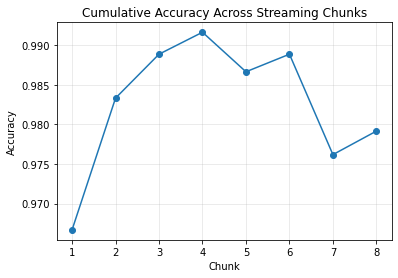

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

In [7]:
output_dir = PROJECT_ROOT / "outputs"
output_dir.mkdir(exist_ok=True)
# to store the output plot in the local access.
accuracy_plot_path = output_dir / "streaming_accuracy_notebook.png"
print("The plot shows the accuracy across streaming chunks to the accuracy")
plot_metric_over_time(
    cumulative_accuracies,
    title="Cumulative Accuracy Across Streaming Chunks",
    ylabel="Accuracy",
    save_path=str(accuracy_plot_path),
    show=True,
)


## 7. Visualise predictions versus ground truth

This plot compares predicted labels and true labels for the latest chunk.



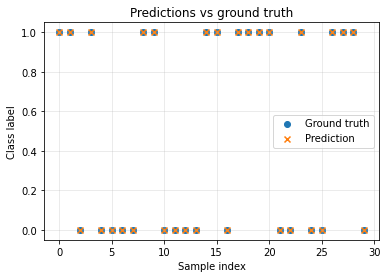

Saved plot: C:\Users\vcsd2\Downloads\Assignment2.2_individual_streaming_update\outputs\predictions_vs_ground_truth_notebook.png


<Figure size 432x288 with 0 Axes>

In [8]:
pred_plot_path = output_dir / "predictions_vs_ground_truth_notebook.png"

plot_predictions_vs_ground_truth(
    latest_y,
    latest_pred,
    save_path=str(pred_plot_path),
    show=True,
)

print("Saved plot:", pred_plot_path)

## 8. Optional model comparison plot

This compares chunk accuracy and cumulative accuracy.  
It is not comparing two different models, but it clearly shows the difference between local chunk performance and overall accumulated performance.



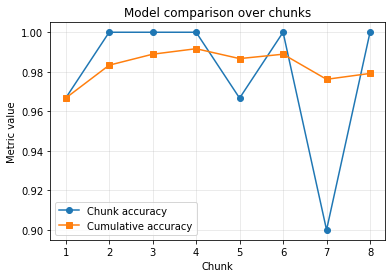

Saved plot: C:\Users\vcsd2\Downloads\Assignment2.2_individual_streaming_update\outputs\chunk_vs_cumulative_accuracy_notebook.png


<Figure size 432x288 with 0 Axes>

In [9]:
comparison_plot_path = output_dir / "chunk_vs_cumulative_accuracy_notebook.png"

compare_models(
    chunk_accuracies,
    cumulative_accuracies,
    labels=("Chunk accuracy", "Cumulative accuracy"),
    save_path=str(comparison_plot_path),
    show=True,
)

print("Saved plot:", comparison_plot_path)